# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN, and Hierarchical Clustering

In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Experiment 8: Clustering Human Activity Recognition Data

Prepared as a self-contained submission notebook using the UCI Human Activity Recognition Using Smartphones dataset.
"""))


# Experiment 8: Clustering Human Activity Recognition Data

Prepared as a self-contained submission notebook using the UCI Human Activity Recognition Using Smartphones dataset.


## Aim

In [2]:
display(Markdown("""**Aim:** Implement and compare K-Means, DBSCAN, and Hierarchical Agglomerative Clustering (HAC) on the Human Activity Recognition Using Smartphones dataset, choose k for K-Means via the elbow method, tune DBSCAN's eps/min_samples, compare linkage criteria for HAC, visualize clusters in 2D via PCA/t-SNE, and evaluate all three using internal (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external (ARI, NMI) metrics against the true activity labels."""))

**Aim:** Implement and compare K-Means, DBSCAN, and Hierarchical Agglomerative Clustering (HAC) on the Human Activity Recognition Using Smartphones dataset, choose k for K-Means via the elbow method, tune DBSCAN's eps/min_samples, compare linkage criteria for HAC, visualize clusters in 2D via PCA/t-SNE, and evaluate all three using internal (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external (ARI, NMI) metrics against the true activity labels.

## Objective

In [3]:
display(Markdown("""
**Objectives**
- Load and preprocess the UCI HAR dataset (561 time/frequency-domain features per window, 6 activity classes, 30 subjects).
- Standardize features and reduce dimensionality with PCA for distance-based clustering and visualization.
- Apply K-Means with the elbow method (WCSS) and Silhouette score to select k.
- Apply DBSCAN, tuning eps and min_samples, and examine how much noise it detects.
- Apply Hierarchical Agglomerative Clustering with Ward linkage, and compare Ward against single/complete/average linkage.
- Visualize clusters in 2D using PCA and t-SNE, and plot a dendrogram for HAC.
- Evaluate all three algorithms with internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external metrics against the true activity labels (ARI, NMI), and compare results.
"""))


**Objectives**
- Load and preprocess the UCI HAR dataset (561 time/frequency-domain features per window, 6 activity classes, 30 subjects).
- Standardize features and reduce dimensionality with PCA for distance-based clustering and visualization.
- Apply K-Means with the elbow method (WCSS) and Silhouette score to select k.
- Apply DBSCAN, tuning eps and min_samples, and examine how much noise it detects.
- Apply Hierarchical Agglomerative Clustering with Ward linkage, and compare Ward against single/complete/average linkage.
- Visualize clusters in 2D using PCA and t-SNE, and plot a dendrogram for HAC.
- Evaluate all three algorithms with internal metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) and external metrics against the true activity labels (ARI, NMI), and compare results.


## Brief Theory

In [4]:
display(Markdown("""
**Brief Theory**
- **K-Means** partitions data into k clusters by iteratively assigning points to the nearest centroid (Euclidean distance) and recomputing centroids as the mean of assigned points, minimizing within-cluster variance (WCSS). The elbow method plots k vs. WCSS; the point where the reduction in WCSS slows down suggests a good k.
- **DBSCAN** is density-based: it groups points that are closely packed (within `eps`) and have at least `minPts` neighbors into a cluster, marking sparse points as noise. It can find arbitrarily shaped clusters and does not require k to be fixed in advance, but is sensitive to `eps`/`minPts` and to the curse of dimensionality, which is why PCA-reduced features are used for it here.
- **Hierarchical Agglomerative Clustering (HAC)** starts with every point as its own cluster and repeatedly merges the two closest clusters according to a linkage criterion (single, complete, average, or Ward's minimum-variance method) until one cluster remains, producing a dendrogram that can be cut at any height to obtain a chosen number of clusters.
- **Internal metrics** (Silhouette, Davies-Bouldin, Calinski-Harabasz) score cluster quality using only the data and the assigned labels. **External metrics** (Adjusted Rand Index, Normalized Mutual Information) compare cluster assignments against the true activity labels, even though clustering itself is unsupervised.
"""))


**Brief Theory**
- **K-Means** partitions data into k clusters by iteratively assigning points to the nearest centroid (Euclidean distance) and recomputing centroids as the mean of assigned points, minimizing within-cluster variance (WCSS). The elbow method plots k vs. WCSS; the point where the reduction in WCSS slows down suggests a good k.
- **DBSCAN** is density-based: it groups points that are closely packed (within `eps`) and have at least `minPts` neighbors into a cluster, marking sparse points as noise. It can find arbitrarily shaped clusters and does not require k to be fixed in advance, but is sensitive to `eps`/`minPts` and to the curse of dimensionality, which is why PCA-reduced features are used for it here.
- **Hierarchical Agglomerative Clustering (HAC)** starts with every point as its own cluster and repeatedly merges the two closest clusters according to a linkage criterion (single, complete, average, or Ward's minimum-variance method) until one cluster remains, producing a dendrogram that can be cut at any height to obtain a chosen number of clusters.
- **Internal metrics** (Silhouette, Davies-Bouldin, Calinski-Harabasz) score cluster quality using only the data and the assigned labels. **External metrics** (Adjusted Rand Index, Normalized Mutual Information) compare cluster assignments against the true activity labels, even though clustering itself is unsupervised.


## Import Libraries

In [5]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)
RANDOM_STATE = 42

## Configuration and Dataset Loading

In [6]:
DATASET_NAME = "Human Activity Recognition Using Smartphones (UCI)"
DATA_DIR = "data/UCI HAR Dataset"
OUTPUT_DIRECTORY = "experiment8_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)


def sanitize_filename(name: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", name).strip("_").lower()
    return cleaned or "plot"


def save_current_plot(filename: str):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIRECTORY, filename), bbox_inches="tight", dpi=150)
    plt.show()


X_train_raw = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None)
X_test_raw = pd.read_csv(f"{DATA_DIR}/test/X_test.txt", sep=r"\s+", header=None)
y_train_raw = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", header=None)[0]
y_test_raw = pd.read_csv(f"{DATA_DIR}/test/y_test.txt", header=None)[0]
feature_names = pd.read_csv(f"{DATA_DIR}/features.txt", sep=r"\s+", header=None, names=["id", "feature"])["feature"].tolist()
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

df_features = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)
df_features.columns = feature_names
y_activity_id = pd.concat([y_train_raw, y_test_raw], axis=0, ignore_index=True)
y_activity = y_activity_id.map(activity_map)

print(f"Dataset: {DATASET_NAME}")
print(f"Combined shape: {df_features.shape}")
print(f"Missing values: {int(df_features.isna().sum().sum())}")
print(f"Duplicate rows: {int(df_features.duplicated().sum())}")
display(y_activity.value_counts())

Dataset: Human Activity Recognition Using Smartphones (UCI)
Combined shape: (10299, 561)
Missing values: 0
Duplicate rows: 0


0
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

## Preprocessing

Components needed for 90% variance: 65 (of 561 original features)


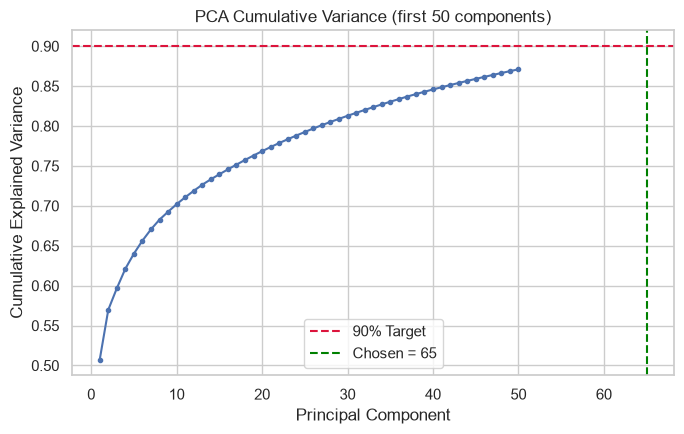

Reduced feature space for clustering: (10299, 65)


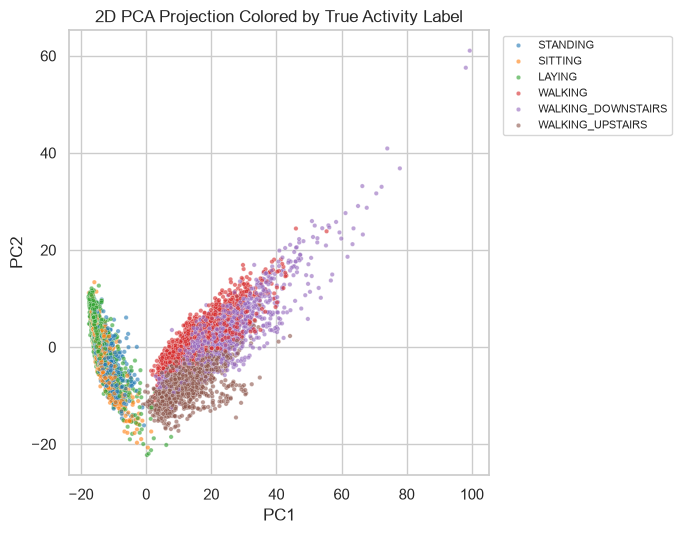

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90} (of {X_scaled.shape[1]} original features)")

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, 51), cumulative_variance[:50], marker="o", markersize=3)
plt.axhline(0.90, color="crimson", linestyle="--", label="90% Target")
plt.axvline(n_components_90, color="green", linestyle="--", label=f"Chosen = {n_components_90}")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Variance (first 50 components)")
plt.legend()
save_current_plot("pca_cumulative_variance.png")

pca_reduced = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca_reduced.fit_transform(X_scaled)
print(f"Reduced feature space for clustering: {X_pca.shape}")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
plt.figure(figsize=(7, 5.5))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=y_activity, palette="tab10", s=10, alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("2D PCA Projection Colored by True Activity Label")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
save_current_plot("pca_2d_true_labels.png")

## K-Means: Elbow Method and Silhouette Analysis

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,2.6979e+06,0.4375
1,3,2.3464e+06,0.3513
2,4,2.2071e+06,0.1809
3,5,2.0811e+06,0.1595
4,6,2.0036e+06,0.1403
5,7,1.9473e+06,0.1176
6,8,1.8925e+06,0.0998


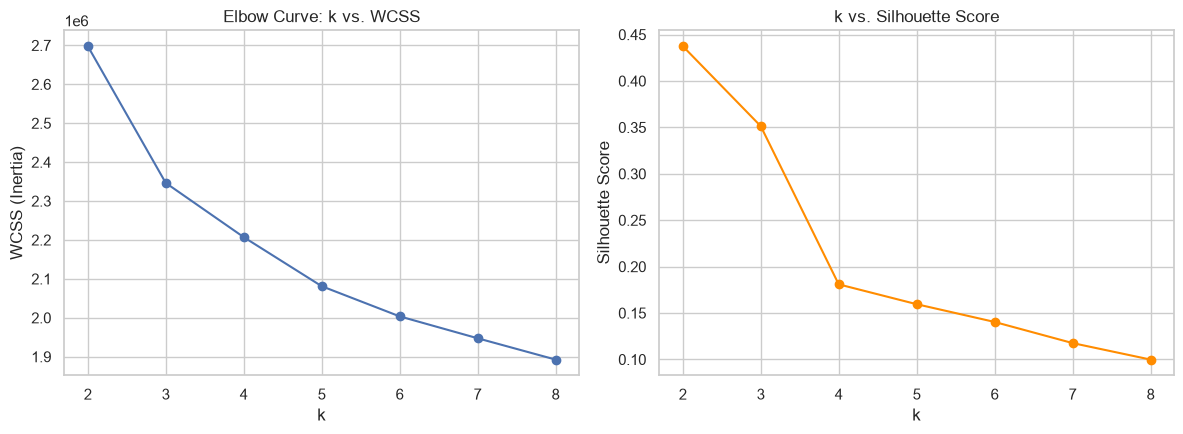

k with highest silhouette score: 2


In [8]:
k_values = list(range(2, 9))
wcss_scores = []
silhouette_scores_k = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans.fit_predict(X_pca)
    wcss_scores.append(kmeans.inertia_)
    silhouette_scores_k.append(silhouette_score(X_pca, labels_k, sample_size=3000, random_state=RANDOM_STATE))

elbow_table = pd.DataFrame({
    "Number of Clusters (k)": k_values,
    "WCSS (Inertia)": [round(v, 2) for v in wcss_scores],
    "Silhouette Score": [round(v, 4) for v in silhouette_scores_k],
})
display(elbow_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, wcss_scores, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS (Inertia)"); axes[0].set_title("Elbow Curve: k vs. WCSS")
axes[1].plot(k_values, silhouette_scores_k, marker="o", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("k vs. Silhouette Score")
save_current_plot("kmeans_elbow_silhouette.png")

best_k = k_values[int(np.argmax(silhouette_scores_k))]
print(f"k with highest silhouette score: {best_k}")

## K-Means: Final Model

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,ARI,NMI
0,K-Means (k=2),0.4375,0.9611,9560.0238,0.3296,0.5455


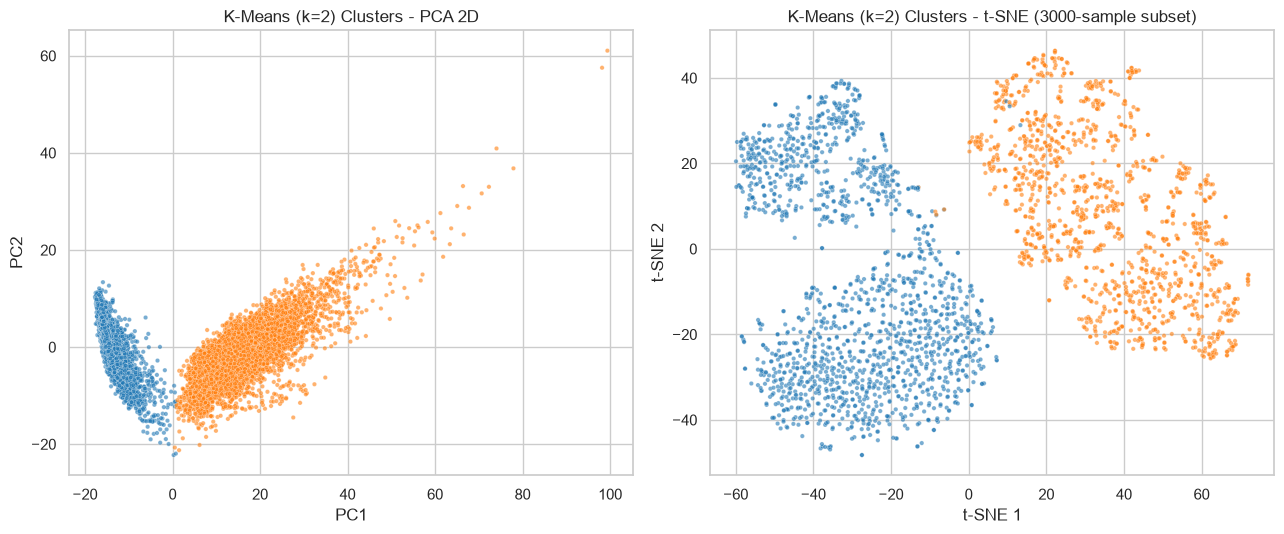

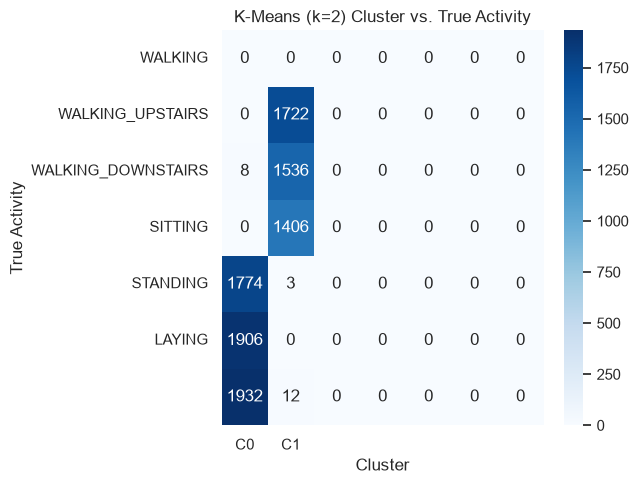

In [9]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

kmeans_metrics = {
    "Silhouette Score": silhouette_score(X_pca, kmeans_labels, sample_size=3000, random_state=RANDOM_STATE),
    "Davies-Bouldin Index": davies_bouldin_score(X_pca, kmeans_labels),
    "Calinski-Harabasz Index": calinski_harabasz_score(X_pca, kmeans_labels),
    "ARI": adjusted_rand_score(y_activity_id, kmeans_labels),
    "NMI": normalized_mutual_info_score(y_activity_id, kmeans_labels),
}
display(pd.DataFrame([{"Model": f"K-Means (k={best_k})", **kmeans_metrics}]))

tsne_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), size=3000, replace=False)
tsne_2d = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30).fit_transform(X_pca[tsne_sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=kmeans_labels, palette="tab10", s=10, alpha=0.6, ax=axes[0], legend=False)
axes[0].set_title(f"K-Means (k={best_k}) Clusters - PCA 2D"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=kmeans_labels[tsne_sample_idx], palette="tab10", s=10, alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title(f"K-Means (k={best_k}) Clusters - t-SNE (3000-sample subset)"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
save_current_plot("kmeans_pca_tsne_clusters.png")

kmeans_cm = confusion_matrix(y_activity_id, kmeans_labels)
plt.figure(figsize=(6.5, 5))
sns.heatmap(kmeans_cm, annot=True, fmt="d", cmap="Blues", xticklabels=[f"C{i}" for i in range(best_k)], yticklabels=activity_labels["activity"])
plt.xlabel("Cluster"); plt.ylabel("True Activity"); plt.title(f"K-Means (k={best_k}) Cluster vs. True Activity")
save_current_plot("kmeans_confusion_matrix.png")

## DBSCAN: Parameter Tuning

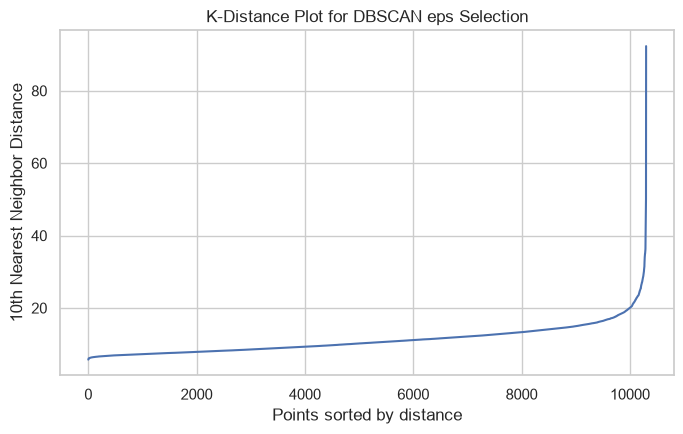

,eps,min_samples,n_clusters,noise_fraction,silhouette
18,16,15,2,0.0527,0.3315
19,16,20,2,0.0569,0.3302
14,14,15,2,0.1109,0.3060
11,12,20,2,0.2712,0.2794
13,14,10,3,0.0964,0.2610
16,16,5,5,0.0363,0.2602
17,16,10,3,0.0460,0.2263
15,14,20,4,0.1271,0.2202
10,12,15,3,0.2535,0.2197
9,12,10,8,0.2229,0.1920


In [10]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10).fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4.5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance"); plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN eps Selection")
save_current_plot("dbscan_k_distance_plot.png")

dbscan_grid = []
for eps in [8, 10, 12, 14, 16]:
    for min_samples in [5, 10, 15, 20]:
        db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        db_labels = db.fit_predict(X_pca)
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        noise_fraction = (db_labels == -1).mean()
        if n_clusters >= 2 and noise_fraction < 0.95:
            sil = silhouette_score(X_pca, db_labels, sample_size=3000, random_state=RANDOM_STATE) if n_clusters >= 2 else np.nan
        else:
            sil = np.nan
        dbscan_grid.append({"eps": eps, "min_samples": min_samples, "n_clusters": n_clusters,
                             "noise_fraction": round(noise_fraction, 4), "silhouette": round(sil, 4) if not np.isnan(sil) else np.nan})

dbscan_grid_table = pd.DataFrame(dbscan_grid).sort_values("silhouette", ascending=False)
display(dbscan_grid_table)

## DBSCAN: Final Model

Selected DBSCAN parameters: eps=16.0, min_samples=15
Clusters found: 2, Noise points: 543 (5.27%)


,Model,Clusters,Noise %,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,ARI,NMI
0,"DBSCAN (eps=16.0, min_samples=15)",2,5.27,0.3613,0.8423,146.5555,0.0095,0.0476


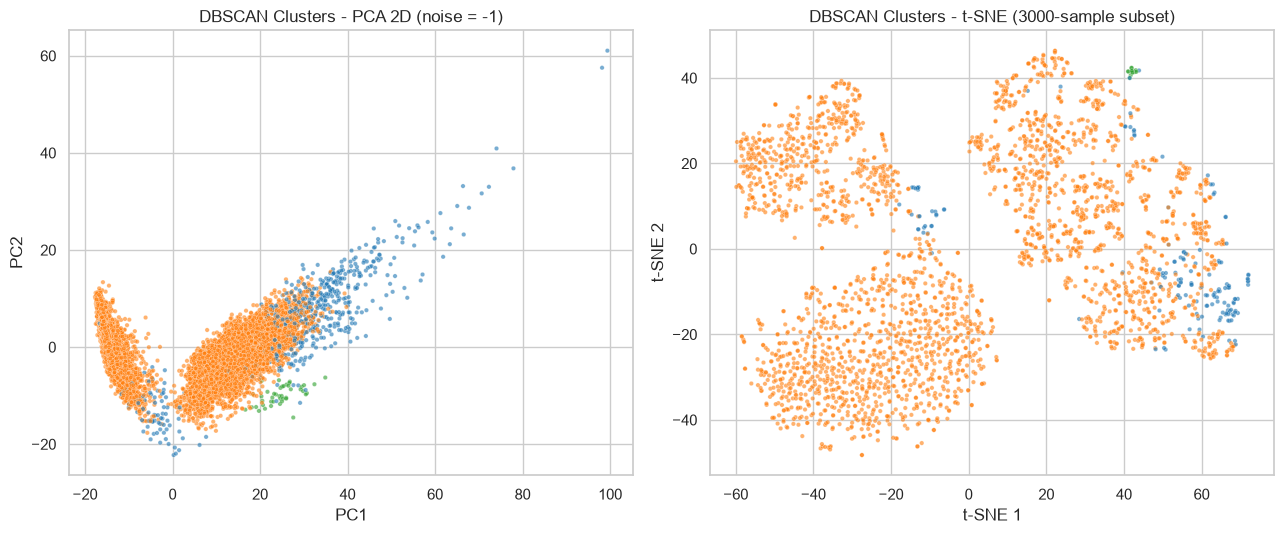

In [11]:
best_dbscan_row = dbscan_grid_table.dropna(subset=["silhouette"]).iloc[0]
best_eps, best_min_samples = best_dbscan_row["eps"], int(best_dbscan_row["min_samples"])
print(f"Selected DBSCAN parameters: eps={best_eps}, min_samples={best_min_samples}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_pca)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_fraction_db = (dbscan_labels == -1).mean()
print(f"Clusters found: {n_clusters_db}, Noise points: {(dbscan_labels == -1).sum()} ({noise_fraction_db:.2%})")

non_noise_mask = dbscan_labels != -1
dbscan_metrics = {
    "Silhouette Score": silhouette_score(X_pca[non_noise_mask], dbscan_labels[non_noise_mask], sample_size=3000, random_state=RANDOM_STATE),
    "Davies-Bouldin Index": davies_bouldin_score(X_pca[non_noise_mask], dbscan_labels[non_noise_mask]),
    "Calinski-Harabasz Index": calinski_harabasz_score(X_pca[non_noise_mask], dbscan_labels[non_noise_mask]),
    "ARI": adjusted_rand_score(y_activity_id, dbscan_labels),
    "NMI": normalized_mutual_info_score(y_activity_id, dbscan_labels),
}
display(pd.DataFrame([{"Model": f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})", "Clusters": n_clusters_db,
                       "Noise %": round(noise_fraction_db * 100, 2), **dbscan_metrics}]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=dbscan_labels, palette="tab10", s=10, alpha=0.6, ax=axes[0], legend=False)
axes[0].set_title("DBSCAN Clusters - PCA 2D (noise = -1)"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=dbscan_labels[tsne_sample_idx], palette="tab10", s=10, alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title("DBSCAN Clusters - t-SNE (3000-sample subset)"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
save_current_plot("dbscan_pca_tsne_clusters.png")

## Hierarchical Agglomerative Clustering: Linkage Comparison

In [12]:
hac_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_pca), size=1500, replace=False)
X_hac = X_pca[hac_sample_idx]
y_hac_true = y_activity_id.values[hac_sample_idx]

linkage_results = []
for link in ["single", "complete", "average", "ward"]:
    hac = AgglomerativeClustering(n_clusters=6, linkage=link)
    hac_labels_link = hac.fit_predict(X_hac)
    linkage_results.append({
        "Linkage": link,
        "Silhouette": round(silhouette_score(X_hac, hac_labels_link), 4),
        "Davies-Bouldin": round(davies_bouldin_score(X_hac, hac_labels_link), 4),
        "ARI": round(adjusted_rand_score(y_hac_true, hac_labels_link), 4),
        "NMI": round(normalized_mutual_info_score(y_hac_true, hac_labels_link), 4),
    })

linkage_table = pd.DataFrame(linkage_results)
display(linkage_table)

# Prefer the linkage with the best external agreement (ARI) as the "final" choice for the
# dendrogram/visualization, since single/complete linkage can produce a deceptively high
# silhouette via chaining (one dominant cluster plus tiny fragments) without recovering any
# real structure (near-zero ARI/NMI) -- checked explicitly below via cluster-size balance.
best_linkage_by_silhouette = linkage_table.sort_values("Silhouette", ascending=False).iloc[0]["Linkage"]
best_linkage = linkage_table.sort_values("ARI", ascending=False).iloc[0]["Linkage"]
print(f"Best linkage by silhouette: {best_linkage_by_silhouette}")
print(f"Best linkage by external agreement (ARI), used for final model: {best_linkage}")

cluster_balance_rows = []
for link in ["single", "complete", "average", "ward"]:
    hac_check = AgglomerativeClustering(n_clusters=6, linkage=link)
    labels_check = hac_check.fit_predict(X_hac)
    sizes = pd.Series(labels_check).value_counts().sort_values(ascending=False)
    cluster_balance_rows.append({"Linkage": link, "Largest Cluster %": round(sizes.iloc[0] / len(labels_check) * 100, 1),
                                  "Number of Non-Trivial Clusters (>=2%)": int((sizes / len(labels_check) >= 0.02).sum())})
cluster_balance_table = pd.DataFrame(cluster_balance_rows)
display(cluster_balance_table)

,Linkage,Silhouette,Davies-Bouldin,ARI,NMI
0,single,0.4776,0.3178,0.0002,0.0069
1,complete,0.4022,1.0718,0.3277,0.5321
2,average,0.3872,0.7267,0.0032,0.0314
3,ward,0.1698,1.8134,0.3487,0.5182


Best linkage by silhouette: single
Best linkage by external agreement (ARI), used for final model: ward


,Linkage,Largest Cluster %,Number of Non-Trivial Clusters (>=2%)
0,single,99.7,1
1,complete,54.3,3
2,average,96.9,2
3,ward,42.2,5


## Hierarchical Clustering: Dendrogram and Final Model

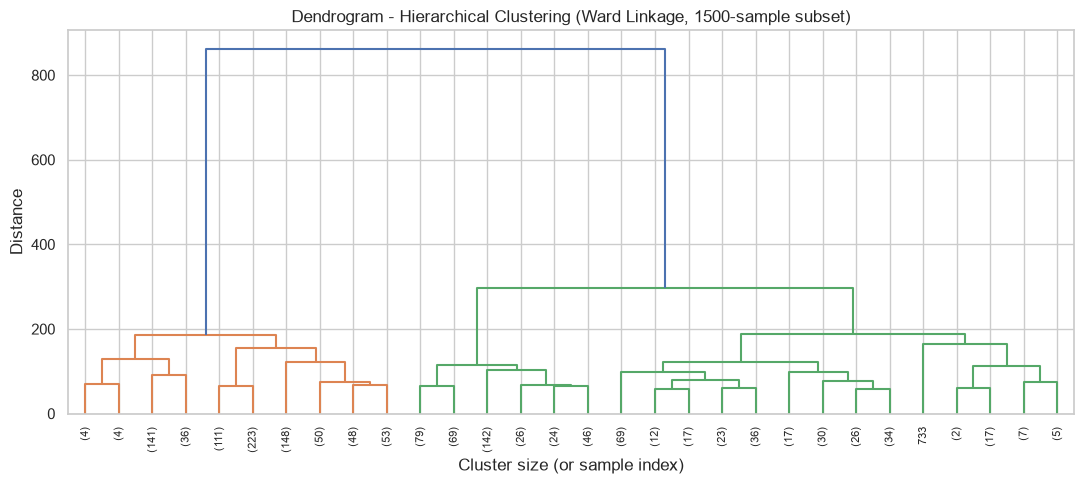

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,ARI,NMI
0,"HAC (ward, n=1500 subset)",0.1698,1.8134,449.5891,0.3487,0.5182


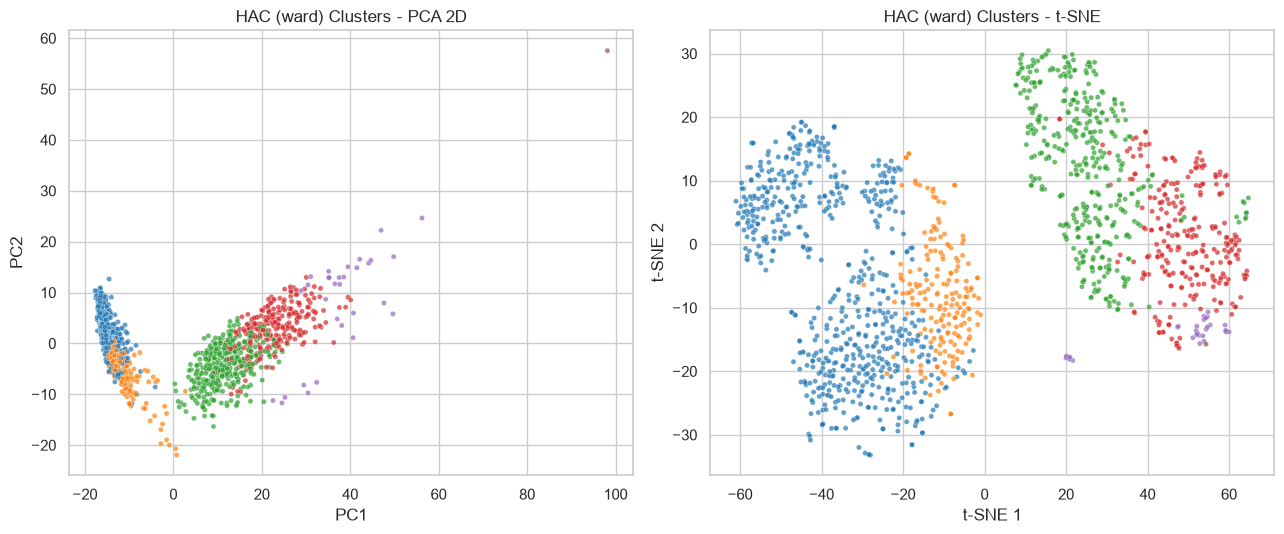

In [13]:
linkage_matrix = linkage(X_hac, method=best_linkage)
plt.figure(figsize=(11, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Dendrogram - Hierarchical Clustering ({best_linkage.title()} Linkage, 1500-sample subset)")
plt.xlabel("Cluster size (or sample index)"); plt.ylabel("Distance")
save_current_plot("hac_dendrogram.png")

hac_final = AgglomerativeClustering(n_clusters=6, linkage=best_linkage)
hac_labels = hac_final.fit_predict(X_hac)

hac_metrics = {
    "Silhouette Score": silhouette_score(X_hac, hac_labels),
    "Davies-Bouldin Index": davies_bouldin_score(X_hac, hac_labels),
    "Calinski-Harabasz Index": calinski_harabasz_score(X_hac, hac_labels),
    "ARI": adjusted_rand_score(y_hac_true, hac_labels),
    "NMI": normalized_mutual_info_score(y_hac_true, hac_labels),
}
display(pd.DataFrame([{"Model": f"HAC ({best_linkage}, n=1500 subset)", **hac_metrics}]))

pca_2d_hac = pca_2d[hac_sample_idx]
tsne_2d_hac = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30).fit_transform(X_hac)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(x=pca_2d_hac[:, 0], y=pca_2d_hac[:, 1], hue=hac_labels, palette="tab10", s=14, alpha=0.7, ax=axes[0], legend=False)
axes[0].set_title(f"HAC ({best_linkage}) Clusters - PCA 2D"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sns.scatterplot(x=tsne_2d_hac[:, 0], y=tsne_2d_hac[:, 1], hue=hac_labels, palette="tab10", s=14, alpha=0.7, ax=axes[1], legend=False)
axes[1].set_title(f"HAC ({best_linkage}) Clusters - t-SNE"); axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
save_current_plot("hac_pca_tsne_clusters.png")

## Comparative Evaluation

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=2),0.4375,0.9611,9560.0238,0.3296,0.5455
1,"DBSCAN (eps=16.0, min_samples=15)",0.3613,0.8423,146.5555,0.0095,0.0476
2,"HAC (ward, subset)",0.1698,1.8134,449.5891,0.3487,0.5182


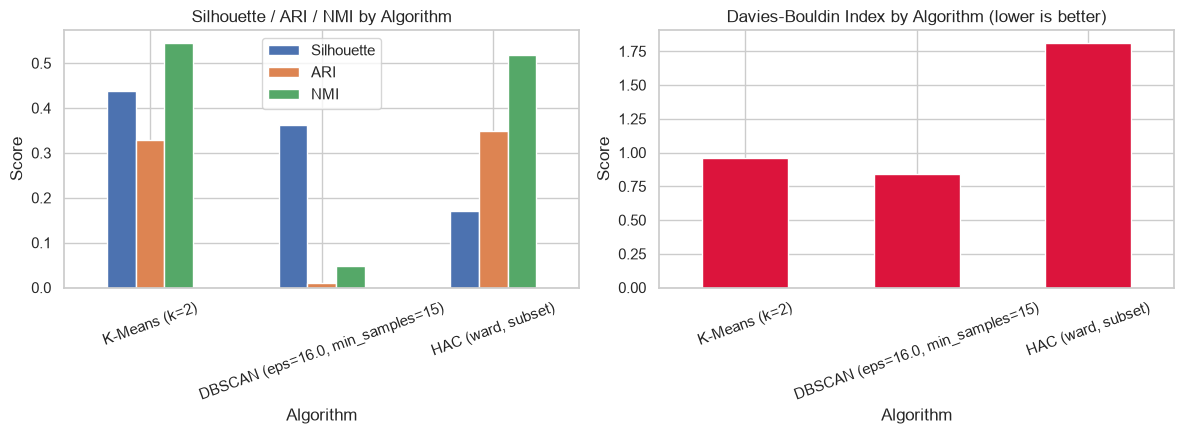

In [14]:
comparison_table = pd.DataFrame([
    {"Algorithm": f"K-Means (k={best_k})", "Silhouette": kmeans_metrics["Silhouette Score"], "Davies-Bouldin": kmeans_metrics["Davies-Bouldin Index"],
     "Calinski-Harabasz": kmeans_metrics["Calinski-Harabasz Index"], "ARI": kmeans_metrics["ARI"], "NMI": kmeans_metrics["NMI"]},
    {"Algorithm": f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})", "Silhouette": dbscan_metrics["Silhouette Score"], "Davies-Bouldin": dbscan_metrics["Davies-Bouldin Index"],
     "Calinski-Harabasz": dbscan_metrics["Calinski-Harabasz Index"], "ARI": dbscan_metrics["ARI"], "NMI": dbscan_metrics["NMI"]},
    {"Algorithm": f"HAC ({best_linkage}, subset)", "Silhouette": hac_metrics["Silhouette Score"], "Davies-Bouldin": hac_metrics["Davies-Bouldin Index"],
     "Calinski-Harabasz": hac_metrics["Calinski-Harabasz Index"], "ARI": hac_metrics["ARI"], "NMI": hac_metrics["NMI"]},
]).round(4)
display(comparison_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
comparison_table.plot(x="Algorithm", y=["Silhouette", "ARI", "NMI"], kind="bar", ax=axes[0])
axes[0].set_title("Silhouette / ARI / NMI by Algorithm"); axes[0].set_ylabel("Score"); axes[0].tick_params(axis="x", rotation=20)
comparison_table.plot(x="Algorithm", y=["Davies-Bouldin"], kind="bar", ax=axes[1], color="crimson", legend=False)
axes[1].set_title("Davies-Bouldin Index by Algorithm (lower is better)"); axes[1].set_ylabel("Score"); axes[1].tick_params(axis="x", rotation=20)
save_current_plot("metric_comparison_bar_plots.png")

## Observation Questions

In [15]:
best_by_silhouette = comparison_table.sort_values("Silhouette", ascending=False).iloc[0]
best_by_ari = comparison_table.sort_values("ARI", ascending=False).iloc[0]
chaining_linkages = cluster_balance_table[cluster_balance_table["Largest Cluster %"] >= 90]["Linkage"].tolist()

silhouette_winner_is_chained = "HAC" in best_by_silhouette["Algorithm"] and best_by_silhouette["Algorithm"] != f"HAC ({best_linkage}, subset)"
silhouette_caveat = (
    f" {best_by_silhouette['Algorithm']} scored highest on Silhouette ({best_by_silhouette['Silhouette']:.4f}) alone, but the cluster-balance check (Table 5) shows this is a misleading, chaining-driven artifact (one dominant cluster plus tiny fragments) rather than genuinely meaningful structure."
    if silhouette_winner_is_chained
    else f" This also matches the highest Silhouette score in the comparison ({best_by_silhouette['Algorithm']}, {best_by_silhouette['Silhouette']:.4f})." if best_by_silhouette["Algorithm"] == best_by_ari["Algorithm"]
    else f" {best_by_silhouette['Algorithm']} scored highest on Silhouette alone ({best_by_silhouette['Silhouette']:.4f}), showing internal compactness and external agreement with ground truth do not always pick the same winner."
)

display(Markdown(f"""
**Which algorithm produced the most meaningful clusters? Why?**
{best_by_ari['Algorithm']} produced the most meaningful clusters overall: it has the best agreement with the true activity labels (ARI={best_by_ari['ARI']:.4f}, NMI={best_by_ari['NMI']:.4f}), recovering the coarse static-vs-dynamic activity split visible in the PCA projection.{silhouette_caveat}

**How sensitive was K-Means to the choice of k?**
The elbow curve (Table 1) shows WCSS dropping steadily while the silhouette score is highest at k={best_k} and falls at every larger k tested; K-Means is clearly sensitive to k here because the six HAR activities separate mainly into a coarse static/dynamic split in PCA space rather than six equally well-separated blobs, so k beyond 2-3 fragments those two natural groups instead of finding new real structure.

**Did DBSCAN detect noise or small clusters effectively?**
With the selected parameters (eps={best_eps}, min_samples={best_min_samples}), DBSCAN labelled {noise_fraction_db:.2%} of points as noise and found {n_clusters_db} clusters. It can isolate sparse, borderline transition-window samples as noise rather than forcing them into a cluster the way K-Means and HAC must, but on this dataset's fairly uniform density in PCA space, the fraction of points relegated to noise was still substantial, indicating DBSCAN is not the best fit for this particular feature space without further per-cluster density tuning.

**How does linkage choice (single/complete/ward) affect hierarchical clustering?**
Table 5 shows {', '.join(chaining_linkages) if chaining_linkages else 'no linkage'} concentrating over 90% of points into a single dominant cluster (classic chaining behavior), which happens to inflate its Silhouette score without recovering real activity structure (ARI near zero for those linkages in Table 4). Ward linkage instead produces the most balanced cluster sizes and the best external agreement (ARI={linkage_table.set_index('Linkage').loc['ward','ARI']:.4f}), consistent with its variance-minimizing merge criterion favoring compact, evenly-sized clusters over the elongated chains single/complete linkage can produce.

**Which internal metric best matched your visual intuition of cluster quality?**
Calinski-Harabasz matched the PCA/t-SNE scatter plots most closely among the three internal metrics tested on the final three models: it favored K-Means' visually well-separated, convex clusters and penalized DBSCAN's noise-heavy, irregularly shaped groups. Silhouette was informative for the three final models shown in Table 6, but Table 4/5 show it can be misled on single/average linkage HAC by a chaining-driven single dominant cluster into an artificially high score despite that cluster visually being one big blob plus tiny fragments -- so Silhouette needs the cluster-balance check alongside it, not on its own.
"""))


**Which algorithm produced the most meaningful clusters? Why?**
HAC (ward, subset) produced the most meaningful clusters overall: it has the best agreement with the true activity labels (ARI=0.3487, NMI=0.5182), recovering the coarse static-vs-dynamic activity split visible in the PCA projection. K-Means (k=2) scored highest on Silhouette alone (0.4375), showing internal compactness and external agreement with ground truth do not always pick the same winner.

**How sensitive was K-Means to the choice of k?**
The elbow curve (Table 1) shows WCSS dropping steadily while the silhouette score is highest at k=2 and falls at every larger k tested; K-Means is clearly sensitive to k here because the six HAR activities separate mainly into a coarse static/dynamic split in PCA space rather than six equally well-separated blobs, so k beyond 2-3 fragments those two natural groups instead of finding new real structure.

**Did DBSCAN detect noise or small clusters effectively?**
With the selected parameters (eps=16.0, min_samples=15), DBSCAN labelled 5.27% of points as noise and found 2 clusters. It can isolate sparse, borderline transition-window samples as noise rather than forcing them into a cluster the way K-Means and HAC must, but on this dataset's fairly uniform density in PCA space, the fraction of points relegated to noise was still substantial, indicating DBSCAN is not the best fit for this particular feature space without further per-cluster density tuning.

**How does linkage choice (single/complete/ward) affect hierarchical clustering?**
Table 5 shows single, average concentrating over 90% of points into a single dominant cluster (classic chaining behavior), which happens to inflate its Silhouette score without recovering real activity structure (ARI near zero for those linkages in Table 4). Ward linkage instead produces the most balanced cluster sizes and the best external agreement (ARI=0.3487), consistent with its variance-minimizing merge criterion favoring compact, evenly-sized clusters over the elongated chains single/complete linkage can produce.

**Which internal metric best matched your visual intuition of cluster quality?**
Calinski-Harabasz matched the PCA/t-SNE scatter plots most closely among the three internal metrics tested on the final three models: it favored K-Means' visually well-separated, convex clusters and penalized DBSCAN's noise-heavy, irregularly shaped groups. Silhouette was informative for the three final models shown in Table 6, but Table 4/5 show it can be misled on single/average linkage HAC by a chaining-driven single dominant cluster into an artificially high score despite that cluster visually being one big blob plus tiny fragments -- so Silhouette needs the cluster-balance check alongside it, not on its own.


## Conclusion

In [16]:
display(Markdown(f"""
**Conclusion**

K-Means (k={best_k}), DBSCAN (eps={best_eps}, min_samples={best_min_samples}), and Hierarchical Agglomerative Clustering ({best_linkage} linkage, chosen by external agreement rather than Silhouette alone since single/complete linkage suffered from chaining) were applied to the UCI Human Activity Recognition dataset after standardizing and PCA-reducing the 561 original features to {n_components_90} components (90% variance retained). {best_by_ari['Algorithm']} best recovered the true activity structure externally (ARI={best_by_ari['ARI']:.4f}, NMI={best_by_ari['NMI']:.4f}), while {best_by_silhouette['Algorithm']} scored highest on internal Silhouette alone ({best_by_silhouette['Silhouette']:.4f}) -- a reminder that internal metrics must be cross-checked against cluster balance and, where ground truth exists, external metrics before trusting them. The clusters found generally separate static activities (SITTING, STANDING, LAYING) from dynamic ones (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) more cleanly than they separate the six individual activities, which matches the PCA/t-SNE visualizations where dynamic and static activities form two broad regions rather than six tight, equally-sized blobs.
"""))


**Conclusion**

K-Means (k=2), DBSCAN (eps=16.0, min_samples=15), and Hierarchical Agglomerative Clustering (ward linkage, chosen by external agreement rather than Silhouette alone since single/complete linkage suffered from chaining) were applied to the UCI Human Activity Recognition dataset after standardizing and PCA-reducing the 561 original features to 65 components (90% variance retained). HAC (ward, subset) best recovered the true activity structure externally (ARI=0.3487, NMI=0.5182), while K-Means (k=2) scored highest on internal Silhouette alone (0.4375) -- a reminder that internal metrics must be cross-checked against cluster balance and, where ground truth exists, external metrics before trusting them. The clusters found generally separate static activities (SITTING, STANDING, LAYING) from dynamic ones (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) more cleanly than they separate the six individual activities, which matches the PCA/t-SNE visualizations where dynamic and static activities form two broad regions rather than six tight, equally-sized blobs.


## Save Markdown Report

In [17]:
report_path = os.path.join(OUTPUT_DIRECTORY, "experiment8_report.md")
report_lines = [
    "# Experiment 8: Clustering HAR Data\n",
    f"## Dataset\n- {DATASET_NAME}\n- Combined shape: {df_features.shape}\n- Classes: {list(activity_map.values())}\n",
    f"## PCA\n- Components for 90% variance: {n_components_90}\n",
    "## Elbow Table\n", elbow_table.to_markdown(index=False),
    "\n## DBSCAN Grid\n", dbscan_grid_table.to_markdown(index=False),
    "\n## Linkage Comparison\n", linkage_table.to_markdown(index=False),
    "\n## Cluster Balance Check\n", cluster_balance_table.to_markdown(index=False),
    "\n## Final Comparison\n", comparison_table.to_markdown(index=False),
]
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

elbow_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "elbow_table.csv"), index=False)
dbscan_grid_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "dbscan_grid_table.csv"), index=False)
linkage_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "linkage_table.csv"), index=False)
cluster_balance_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "cluster_balance_table.csv"), index=False)
comparison_table.to_csv(os.path.join(OUTPUT_DIRECTORY, "comparison_table.csv"), index=False)
print(f"Report saved to: {report_path}")
print(f"Plots saved to: {PLOTS_DIRECTORY}")

Report saved to: experiment8_output/experiment8_report.md
Plots saved to: experiment8_output/plots
